# Understanding Impact on Economic Activity

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import acled_conflict_analysis

In [2]:
eth_adm0 = gpd.read_file('../../data/boundaries/eth_admbnda_adm0_csa_bofedb_itos_2021.shp')
eth_adm1 = gpd.read_file('../../data/boundaries/eth_admbnda_adm1_csa_bofedb_2021.shp')
eth_adm2 = gpd.read_file('../../data/boundaries/eth_admbnda_adm2_csa_bofedb_2021.shp')
eth_adm3 = gpd.read_file('../../data/boundaries/eth_admbnda_adm3_csa_bofedb_2021.shp')

In [118]:
eth_adm0_gadm = gpd.read_file('../../data/boundaries/gadm/ETH_GADM_level0.shp')
eth_adm1_gadm = gpd.read_file('../../data/boundaries/gadm/ETH_GADM_level1.shp')
eth_adm2_gadm = gpd.read_file('../../data/boundaries/gadm/ETH_GADM_level2.shp')
#eth_adm3_gadm = gpd.read_file('../../data/boundaries/gadm/ETH_GADM_level3.shp')

In [3]:
evi_adm0_annual = pd.read_csv('../../data/agriculture/processed/eth_evi_yearly_summary_adm0.csv')
evi_adm1_annual = pd.read_csv('../../data/agriculture/processed/eth_evi_yearly_summary_adm1.csv')
evi_adm0_monthly = pd.read_csv('../../data/agriculture/processed/eth_evi_monthly_summary_adm0.csv')
evi_adm1_monthly = pd.read_csv('../../data/agriculture/processed/eth_evi_monthly_summary_adm1.csv')

evi_adm2_annual = pd.read_csv('../../data/agriculture/processed/eth_evi_yearly_summary_adm2.csv')
evi_adm2_monthly = pd.read_csv('../../data/agriculture/processed/eth_evi_monthly_summary_adm2.csv')
evi_adm2_monthly_zscore = pd.read_csv('../../data/agriculture/processed/eth_zscore_adm2_2019_2024.csv')

In [4]:
evi_adm0_annual['date'] = pd.to_datetime(evi_adm0_annual['date'])
evi_adm0_annual.rename(columns={'mean': 'evi_median'}, inplace=True)

In [3]:
airpollution_adm1 = pd.read_csv('../../data/air_pollution/processed/air_pollution_monthly_adm1_2019_2024.csv')
airpollution_adm2 = pd.read_csv('../../data/air_pollution/processed/air_pollution_monthly_adm2_2019_2024.csv')
airpollution_adm3 = pd.read_csv('../../data/air_pollution/processed/eth_adm3_no2_monthly_2019_2024.csv')

C:\Users\wb588851\AppData\Local\Temp\ipykernel_25988\4010708093.py:3: DtypeWarning: Columns (6,10) have mixed types. Specify dtype option on import or set low_memory=False.
  airpollution_adm3 = pd.read_csv('../../data/air_pollution/processed/eth_adm3_no2_monthly_2019_2024.csv')


In [4]:
airpollution_adm0 = airpollution_adm1.groupby(['ADM0_EN', 'event_date'])['NO2'].mean().reset_index()

In [5]:
airpollution_adm0.rename(columns={'event_date': 'date'}, inplace=True)
airpollution_adm1.rename(columns={'event_date': 'date'}, inplace=True)
airpollution_adm2.rename(columns={'event_date': 'date'}, inplace=True)
airpollution_adm3.rename(columns={'start_date': 'date'}, inplace=True)

In [6]:
airpollution_adm0['date'] = pd.to_datetime(airpollution_adm0['date'])
airpollution_adm1['date'] = pd.to_datetime(airpollution_adm1['date'])

In [7]:
airpollution_adm0_annual = airpollution_adm0.groupby(['ADM0_EN', pd.Grouper(key='date', freq='YS')])['NO2'].mean().reset_index()
airpollution_adm1_annual = airpollution_adm1.groupby(['ADM1_EN', pd.Grouper(key='date', freq='YS')])['NO2'].mean().reset_index()

In [15]:
from acled_conflict_analysis import processing

conflict = pd.read_csv('../../data/conflict/acled_raw_20250612.csv')
conflict.rename(columns={'nrFatalities': 'fatalities'}, inplace=True)
processing.data_type_conversion(conflict)
#conflict['event_type'].unique()
conflict = conflict[~(conflict['event_type'].isin(['Strategic developments','Protests']))]

In [16]:
conflict_adm0_monthly = processing.get_acled_by_admin(eth_adm0, conflict, ['ADM0_EN'], freq='MS')
conflict_adm1_monthly = processing.get_acled_by_admin(eth_adm1, conflict, ['ADM1_EN'], freq='MS')
conflict_adm2_monthly = processing.get_acled_by_admin(eth_adm2, conflict, ['ADM1_EN', 'ADM2_EN'], freq='MS')
conflict_adm3_monthly = processing.get_acled_by_admin(eth_adm3, conflict, ['ADM1_EN', 'ADM2_EN', 'ADM3_EN'], freq='MS')

In [21]:
import numpy as np
def get_conflict_index(df):
    df['conflict_index'] = np.sqrt((df['nrEvents']) * (df['nrFatalities'] + 1))

    return df

In [17]:
conflict_adm0_annual = processing.get_acled_by_admin(eth_adm0, conflict, ['ADM0_EN'], freq='YS')
conflict_adm0_annual = processing.get_acled_by_admin(eth_adm0, conflict, ['ADM0_EN'], freq='YS')
conflict_adm1_annual = processing.get_acled_by_admin(eth_adm1, conflict, ['ADM1_EN'], freq='YS')
conflict_adm2_annual = processing.get_acled_by_admin(eth_adm2, conflict, ['ADM1_EN', 'ADM2_EN'], freq='YS')
conflict_adm3_annual = processing.get_acled_by_admin(eth_adm3, conflict, ['ADM1_EN', 'ADM2_EN', 'ADM3_EN'], freq='YS')

In [18]:
conflict_adm0_annual.rename(columns={'event_date': 'date'}, inplace=True)
conflict_adm1_annual.rename(columns={'event_date': 'date'}, inplace=True)
conflict_adm2_annual.rename(columns={'event_date': 'date'}, inplace=True)
conflict_adm3_annual.rename(columns={'event_date': 'date'}, inplace=True)

In [19]:
conflict_adm0_monthly.rename(columns={'event_date': 'date'}, inplace=True)
conflict_adm1_monthly.rename(columns={'event_date': 'date'}, inplace=True)
conflict_adm2_monthly.rename(columns={'event_date': 'date'}, inplace=True)
conflict_adm3_monthly.rename(columns={'event_date': 'date'}, inplace=True)

In [22]:
conflict_adm0_monthly = get_conflict_index(conflict_adm0_monthly)
conflict_adm0_annual = get_conflict_index(conflict_adm0_annual)
conflict_adm1_annual = get_conflict_index(conflict_adm1_annual)

In [23]:
ntl_adm0_monthly = pd.read_csv('../../data/nighttime-lights/processed/ntl_adm0_monthly_2012_2024.csv')
ntl_adm1_monthly = pd.read_csv('../../data/nighttime-lights/processed/ntl_adm1_monthly_2012_2024.csv')
ntl_adm2_monthly = pd.read_csv('../../data/nighttime-lights/processed/ntl_adm2_monthly_2012_2024.csv')

In [24]:
ntl_adm0_monthly['date'] = pd.to_datetime(ntl_adm0_monthly['date'])
ntl_adm0_annual = ntl_adm0_monthly.groupby(['COUNTRY', pd.Grouper(key='date', freq='YS')])[['ntl_sum']].sum().reset_index()

In [25]:
evi_adm0_annual.rename(columns={'admin_area': 'ADM0_EN'}, inplace=True)
evi_adm0_annual['date'] = pd.to_datetime(evi_adm0_annual['date'])
evi_adm0_annual.rename(columns={'mean': 'evi_median'}, inplace=True)
ntl_adm0_annual.rename(columns={'COUNTRY': 'ADM0_EN'}, inplace=True)

In [26]:
merged = pd.merge(airpollution_adm0_annual, conflict_adm0_annual, on=['date', 'ADM0_EN'], how='left')
merged.drop(columns=['index'], inplace=True)

merged = pd.merge(merged, ntl_adm0_annual[['ADM0_EN', 'date', 'ntl_sum']], on=['date', 'ADM0_EN'], how='left')
merged = pd.merge(merged, evi_adm0_annual, on=['date', 'ADM0_EN'], how='left')

## Annual National Trends of EVI, NO2, Conflict and Nightlights

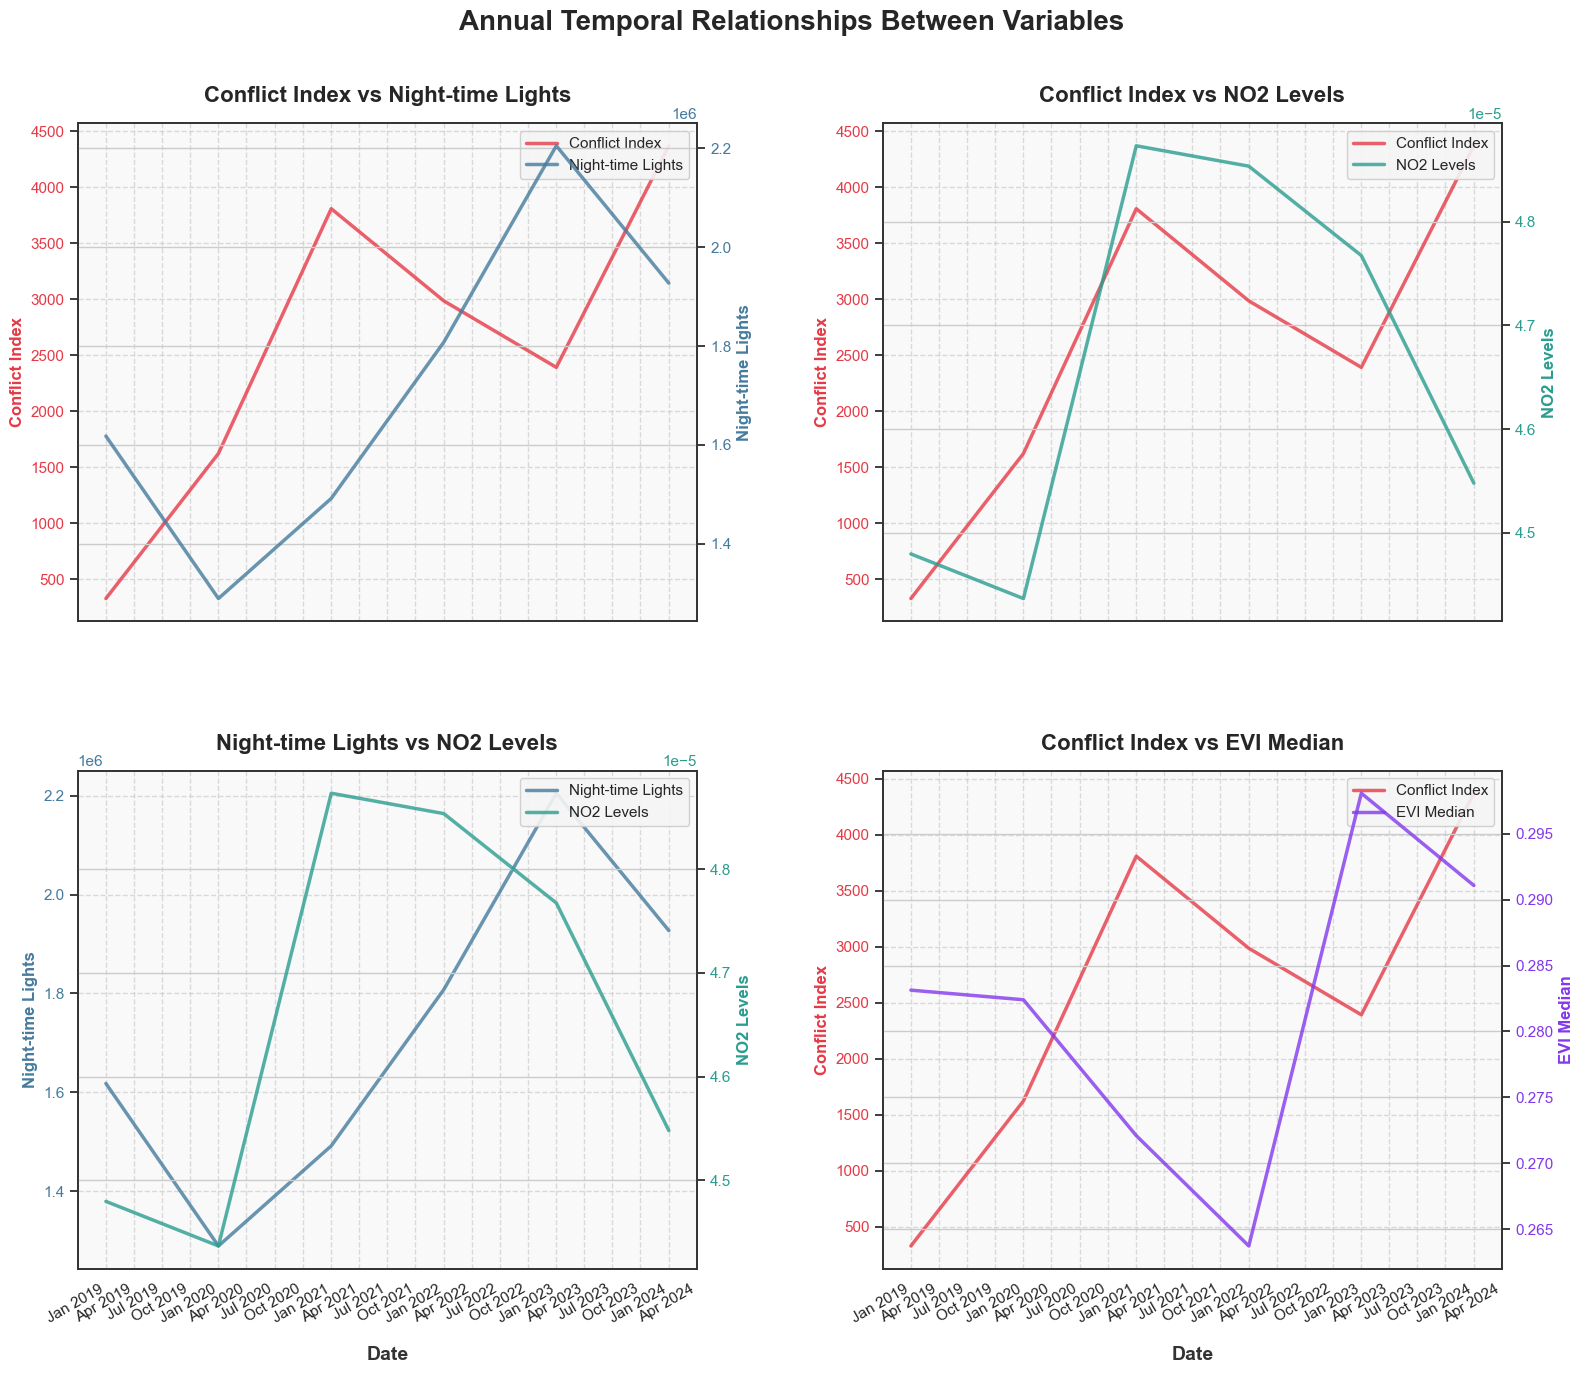

In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator

# Set the style
sns.set(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.facecolor'] = '#f5f5f5'
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.labelcolor'] = '#333333'
plt.rcParams['figure.facecolor'] = 'white'

# Load data
df = merged.copy()

# Set up a color palette
colors = {'conflict': '#E63946', 'ntl': '#457B9D', 'no2': '#2A9D8F', 'evi': '#8338EC'}

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Function to format axis
def format_axis(ax, title, color1, color2):
    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)
    ax.tick_params(axis='both', labelsize=11)
    ax.grid(True, linestyle='--', alpha=0.7)
    
    # Add a subtle background color to highlight the plot area
    ax.set_facecolor('#f9f9f9')
    
    # Format date axis
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

# Plot 1: Conflict vs NTL
ax1 = axes[0, 0]
ax1_twin = ax1.twinx()
sns.lineplot(x='date', y='conflict_index', data=df, color=colors['conflict'], 
             ax=ax1, label='Conflict Index', linewidth=2.5, alpha=0.8)
sns.lineplot(x='date', y='ntl_sum', data=df, color=colors['ntl'], 
             ax=ax1_twin, label='Night-time Lights', linewidth=2.5, alpha=0.8)

format_axis(ax1, 'Conflict Index vs Night-time Lights', colors['conflict'], colors['ntl'])
ax1.set_ylabel('Conflict Index', fontsize=12, color=colors['conflict'], fontweight='bold')
ax1_twin.set_ylabel('Night-time Lights', fontsize=12, color=colors['ntl'], fontweight='bold')
ax1_twin.tick_params(axis='y', labelcolor=colors['ntl'])
ax1.tick_params(axis='y', labelcolor=colors['conflict'])

# Create a combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', 
           frameon=True, framealpha=0.9, fontsize=11)
ax1.get_legend().get_frame().set_edgecolor('#cccccc')
ax1_twin.get_legend().remove()

# Plot 2: Conflict vs NO2
ax2 = axes[0, 1]
ax2_twin = ax2.twinx()
sns.lineplot(x='date', y='conflict_index', data=df, color=colors['conflict'], 
             ax=ax2, label='Conflict Index', linewidth=2.5, alpha=0.8)
sns.lineplot(x='date', y='NO2', data=df, color=colors['no2'], 
             ax=ax2_twin, label='NO2 Levels', linewidth=2.5, alpha=0.8)

format_axis(ax2, 'Conflict Index vs NO2 Levels', colors['conflict'], colors['no2'])
ax2.set_ylabel('Conflict Index', fontsize=12, color=colors['conflict'], fontweight='bold')
ax2_twin.set_ylabel('NO2 Levels', fontsize=12, color=colors['no2'], fontweight='bold')
ax2_twin.tick_params(axis='y', labelcolor=colors['no2'])
ax2.tick_params(axis='y', labelcolor=colors['conflict'])

# Create a combined legend
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right', 
           frameon=True, framealpha=0.9, fontsize=11)
ax2.get_legend().get_frame().set_edgecolor('#cccccc')
ax2_twin.get_legend().remove()

# Plot 3: NTL vs NO2
ax3 = axes[1, 0]
ax3_twin = ax3.twinx()
sns.lineplot(x='date', y='ntl_sum', data=df, color=colors['ntl'], 
             ax=ax3, label='Night-time Lights', linewidth=2.5, alpha=0.8)
sns.lineplot(x='date', y='NO2', data=df, color=colors['no2'], 
             ax=ax3_twin, label='NO2 Levels', linewidth=2.5, alpha=0.8)

format_axis(ax3, 'Night-time Lights vs NO2 Levels', colors['ntl'], colors['no2'])
ax3.set_ylabel('Night-time Lights', fontsize=12, color=colors['ntl'], fontweight='bold')
ax3_twin.set_ylabel('NO2 Levels', fontsize=12, color=colors['no2'], fontweight='bold')
ax3_twin.tick_params(axis='y', labelcolor=colors['no2'])
ax3.tick_params(axis='y', labelcolor=colors['ntl'])

# Create a combined legend
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, loc='upper right', 
           frameon=True, framealpha=0.9, fontsize=11)
ax3.get_legend().get_frame().set_edgecolor('#cccccc')
ax3_twin.get_legend().remove()

# Plot 4: Conflict vs EVI Median (new plot)
ax4 = axes[1, 1]
ax4_twin = ax4.twinx()
sns.lineplot(x='date', y='conflict_index', data=df, color=colors['conflict'], 
             ax=ax4, label='Conflict Index', linewidth=2.5, alpha=0.8)
sns.lineplot(x='date', y='evi_median', data=df, color=colors['evi'], 
             ax=ax4_twin, label='EVI Median', linewidth=2.5, alpha=0.8)

format_axis(ax4, 'Conflict Index vs EVI Median', colors['conflict'], colors['evi'])
ax4.set_ylabel('Conflict Index', fontsize=12, color=colors['conflict'], fontweight='bold')
ax4_twin.set_ylabel('EVI Median', fontsize=12, color=colors['evi'], fontweight='bold')
ax4_twin.tick_params(axis='y', labelcolor=colors['evi'])
ax4.tick_params(axis='y', labelcolor=colors['conflict'])

# Create a combined legend
lines1, labels1 = ax4.get_legend_handles_labels()
lines2, labels2 = ax4_twin.get_legend_handles_labels()
ax4.legend(lines1 + lines2, labels1 + labels2, loc='upper right', 
           frameon=True, framealpha=0.9, fontsize=11)
ax4.get_legend().get_frame().set_edgecolor('#cccccc')
ax4_twin.get_legend().remove()

# Add a dataset title
plt.suptitle('Annual Temporal Relationships Between Variables', 
             fontsize=20, fontweight='bold', y=0.98)

# Add x-axis label to the bottom subplot only
axes[1, 0].set_xlabel('Date', fontsize=14, fontweight='bold', labelpad=15)
axes[1, 1].set_xlabel('Date', fontsize=14, fontweight='bold', labelpad=15)

# Format x-axis dates
plt.gcf().autofmt_xdate()
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.subplots_adjust(hspace=0.3, wspace=0.3)

# Add subtle shadow to figure
plt.savefig('../../docs/images/temporal_relationships.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

**2024 was a reduction in Nightlights, EVI and Air Pollution, while there was an increase in conflict**

**Conflict and Agriculture**
Existing literature showing that the Tigray war from 2020-2022 cause a loss in food security in the Amhara region ([Muhyie, J. H., et. al., 2025](https://pmc.ncbi.nlm.nih.gov/articles/PMC11789359/)). The fall in EVI in these years could be indicative of that, exacerbated by drought. From 19 May to 21 June 2025, the International Red Cross delieverd seed and fertilizer to the people in Amhara to account for [supply chain disruptions](https://www.icrc.org/en/news-release/ethiopia-thousands-receive-seeds-and-fertilizers-conflict-affected-regions#:~:text=The%20armed%20conflicts%20in%20Ethiopia's%20two%20most,to%20widespread%20food%20insecurity%20among%20rural%20communities.) to resources for these farmers. 

Forecasts and predictions suggested that there would be a [conflict and drought-driven loss in agricultural productivity](https://www.fsinplatform.org/sites/default/files/resources/files/GRFC2024-full.pdf#page=71). Although the rain predictions are better than expected, the EVI has fallen which could indicate that conflict has a part to play. 

**NO2, Manufacturing Activity and Movement**
NO2 was seen to reduce in Dire Dawa, a manufacturing hub in Ethiopia. It also reduced across the entire country. This could be both because of reduced movement of vehicles and reduction in industrial production. 

According to the [Ethiopia Statistical Service](https://ess.gov.et/wp-content/uploads/2025/03/external-merchandise-trade-statistics-fourth-quarter-2024.pdf), the number of imports were higher in 2024 compared to 2023, while the exports increased marginally from August-December 2024. 




In [29]:
gdp = pd.read_csv('../../data/general/eth_gdp.csv')
gdp['Year'] = pd.to_datetime(gdp['Year'])
gdp.rename(columns={'Year':'date'}, inplace=True)

In [33]:
merged = merged.merge(gdp, on=['date'], how='left')

## Annual National Trends of EVI, NO2, Conflict and Nightlights with GDP

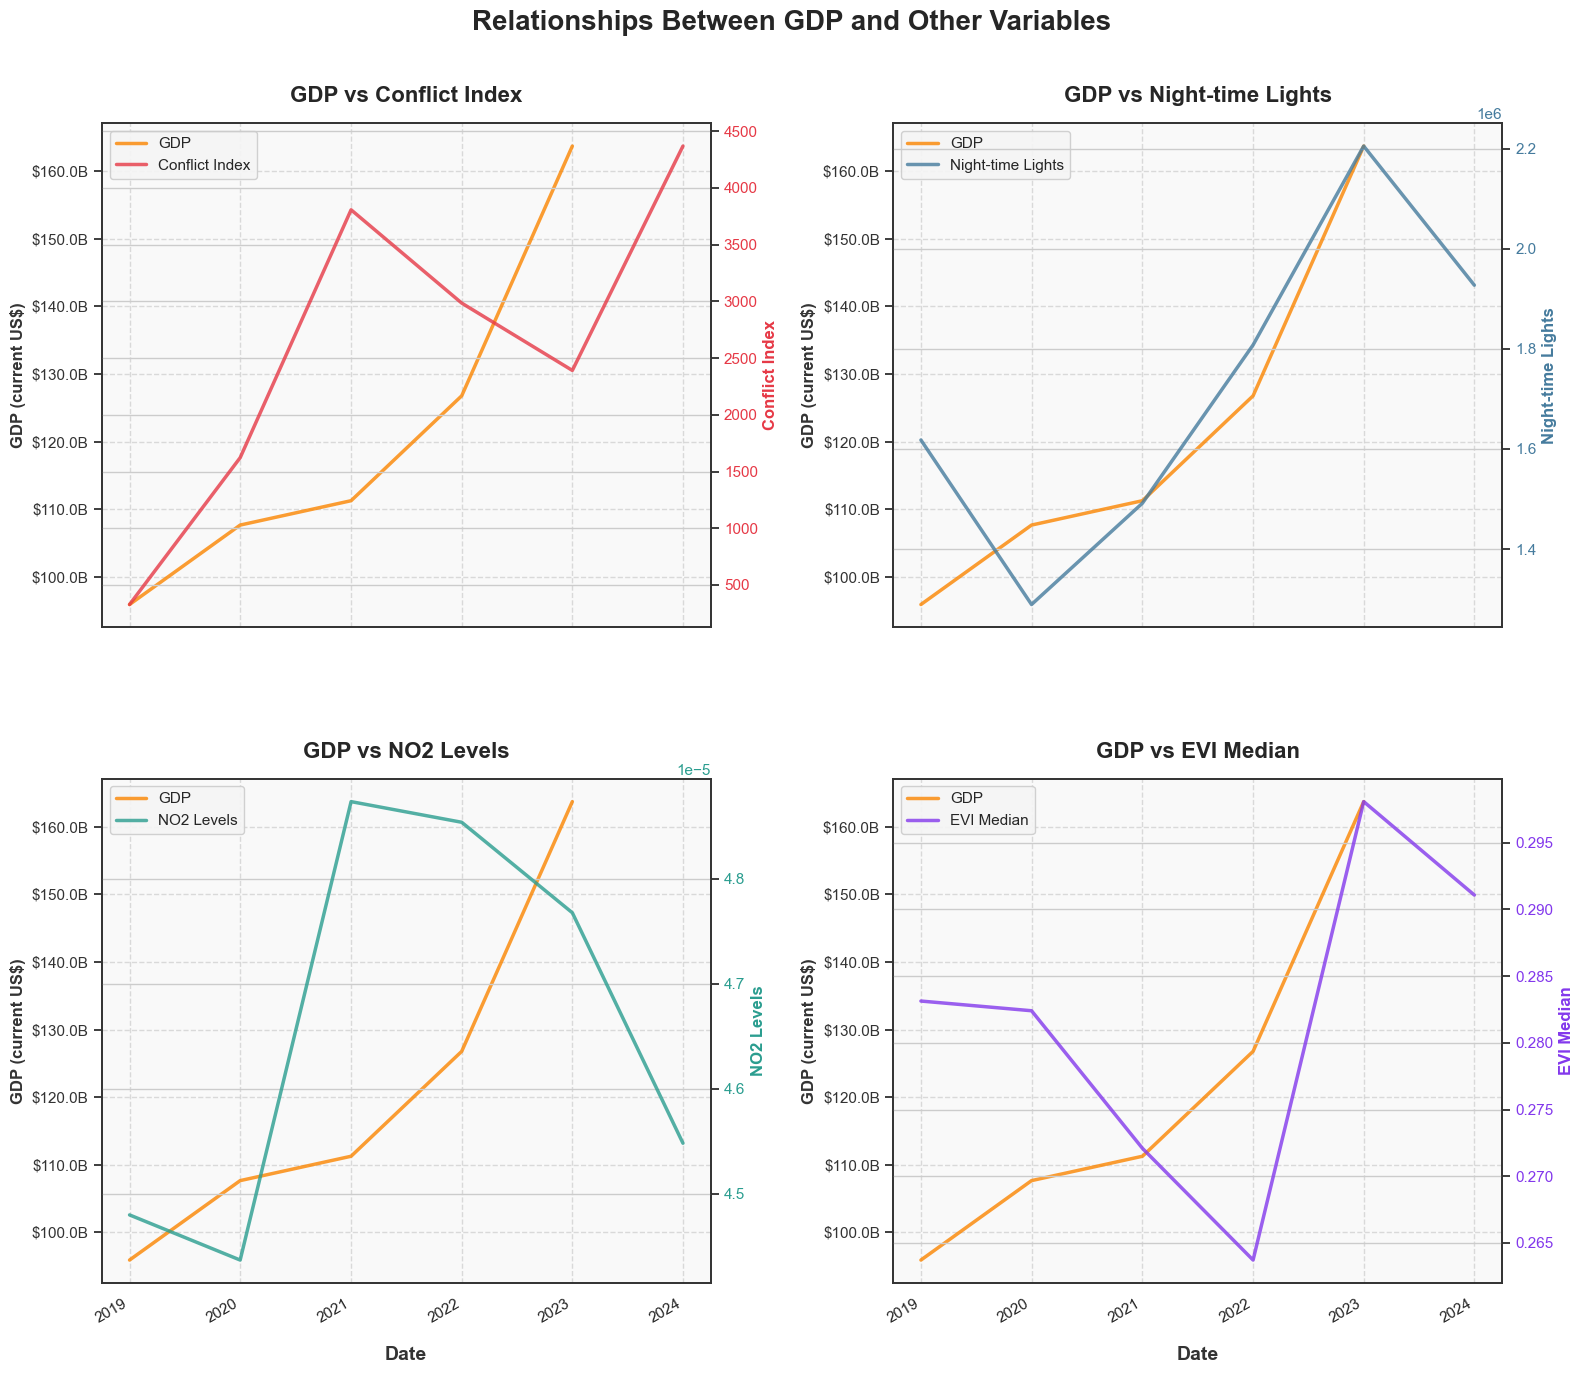

In [35]:
# Set up a color palette
colors = {'conflict': '#E63946', 'ntl': '#457B9D', 'no2': '#2A9D8F', 'evi': '#8338EC', 'gdp': '#FB8500'}

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Function to format axis and create GDP twin axis
def format_axis(ax, title, color1, color2):
    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)
    ax.tick_params(axis='both', labelsize=11)
    ax.grid(True, linestyle='--', alpha=0.7)

    # Add a subtle background color to highlight the plot area
    ax.set_facecolor('#f9f9f9')

    # Format date axis to show only years
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y')) # Changed to show only year
    ax.xaxis.set_major_locator(mdates.YearLocator()) # Changed to show years only

# Function to format GDP values (in billions)
def billions_formatter(x, pos):
    return f'${x/1e9:.1f}B'

# Plot 1: GDP vs Conflict Index
ax1 = axes[0, 0]
ax1_twin = ax1.twinx()
sns.lineplot(x='date', y='GDP (current US$)', data=df, color=colors['gdp'],
             ax=ax1, label='GDP', linewidth=2.5, alpha=0.8)
sns.lineplot(x='date', y='conflict_index', data=df, color=colors['conflict'],
             ax=ax1_twin, label='Conflict Index', linewidth=2.5, alpha=0.8)

format_axis(ax1, 'GDP vs Conflict Index', colors['gdp'], colors['conflict'])
ax1.set_ylabel('GDP (current US$)', fontsize=12, color='#333333', fontweight='bold')
ax1_twin.set_ylabel('Conflict Index', fontsize=12, color=colors['conflict'], fontweight='bold')
ax1_twin.tick_params(axis='y', labelcolor=colors['conflict'])
ax1.tick_params(axis='y', labelcolor='#333333')
ax1.yaxis.set_major_formatter(FuncFormatter(billions_formatter))

# Create a combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left',
           frameon=True, framealpha=0.9, fontsize=11)
ax1.get_legend().get_frame().set_edgecolor('#cccccc')
ax1_twin.get_legend().remove()

# Plot 2: GDP vs NTL
ax2 = axes[0, 1]
ax2_twin = ax2.twinx()
sns.lineplot(x='date', y='GDP (current US$)', data=df, color=colors['gdp'],
             ax=ax2, label='GDP', linewidth=2.5, alpha=0.8)
sns.lineplot(x='date', y='ntl_sum', data=df, color=colors['ntl'],
             ax=ax2_twin, label='Night-time Lights', linewidth=2.5, alpha=0.8)

format_axis(ax2, 'GDP vs Night-time Lights', colors['gdp'], colors['ntl'])
ax2.set_ylabel('GDP (current US$)', fontsize=12, color='#333333', fontweight='bold')
ax2_twin.set_ylabel('Night-time Lights', fontsize=12, color=colors['ntl'], fontweight='bold')
ax2_twin.tick_params(axis='y', labelcolor=colors['ntl'])
ax2.tick_params(axis='y', labelcolor='#333333')
ax2.yaxis.set_major_formatter(FuncFormatter(billions_formatter))

# Create a combined legend
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left',
           frameon=True, framealpha=0.9, fontsize=11)
ax2.get_legend().get_frame().set_edgecolor('#cccccc')
ax2_twin.get_legend().remove()

# Plot 3: GDP vs NO2
ax3 = axes[1, 0]
ax3_twin = ax3.twinx()
sns.lineplot(x='date', y='GDP (current US$)', data=df, color=colors['gdp'],
             ax=ax3, label='GDP', linewidth=2.5, alpha=0.8)
sns.lineplot(x='date', y='NO2', data=df, color=colors['no2'],
             ax=ax3_twin, label='NO2 Levels', linewidth=2.5, alpha=0.8)

format_axis(ax3, 'GDP vs NO2 Levels', colors['gdp'], colors['no2'])
ax3.set_ylabel('GDP (current US$)', fontsize=12, color='#333333', fontweight='bold')
ax3_twin.set_ylabel('NO2 Levels', fontsize=12, color=colors['no2'], fontweight='bold')
ax3_twin.tick_params(axis='y', labelcolor=colors['no2'])
ax3.tick_params(axis='y', labelcolor='#333333')
ax3.yaxis.set_major_formatter(FuncFormatter(billions_formatter))

# Create a combined legend
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, loc='upper left',
           frameon=True, framealpha=0.9, fontsize=11)
ax3.get_legend().get_frame().set_edgecolor('#cccccc')
ax3_twin.get_legend().remove()

# Plot 4: GDP vs EVI Median
ax4 = axes[1, 1]
ax4_twin = ax4.twinx()
sns.lineplot(x='date', y='GDP (current US$)', data=df, color=colors['gdp'],
             ax=ax4, label='GDP', linewidth=2.5, alpha=0.8)
sns.lineplot(x='date', y='evi_median', data=df, color=colors['evi'],
             ax=ax4_twin, label='EVI Median', linewidth=2.5, alpha=0.8)

format_axis(ax4, 'GDP vs EVI Median', colors['gdp'], colors['evi'])
ax4.set_ylabel('GDP (current US$)', fontsize=12, color='#333333', fontweight='bold')
ax4_twin.set_ylabel('EVI Median', fontsize=12, color=colors['evi'], fontweight='bold')
ax4_twin.tick_params(axis='y', labelcolor=colors['evi'])
ax4.tick_params(axis='y', labelcolor='#333333')
ax4.yaxis.set_major_formatter(FuncFormatter(billions_formatter))

# Create a combined legend
lines1, labels1 = ax4.get_legend_handles_labels()
lines2, labels2 = ax4_twin.get_legend_handles_labels()
ax4.legend(lines1 + lines2, labels1 + labels2, loc='upper left',
           frameon=True, framealpha=0.9, fontsize=11)
ax4.get_legend().get_frame().set_edgecolor('#cccccc')
ax4_twin.get_legend().remove()

# Add a dataset title
plt.suptitle('Relationships Between GDP and Other Variables',
             fontsize=20, fontweight='bold', y=0.98)

# Add x-axis label to the bottom subplot only
axes[1, 0].set_xlabel('Date', fontsize=14, fontweight='bold', labelpad=15)
axes[1, 1].set_xlabel('Date', fontsize=14, fontweight='bold', labelpad=15)

# Format x-axis dates
plt.gcf().autofmt_xdate()
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.subplots_adjust(hspace=0.3, wspace=0.3)

# Add subtle shadow to figure
plt.savefig('gdp_relationships_years_only.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')

In [143]:
conflict_adm1_monthly.rename(columns={'event_date':'date'}, inplace=True)
evi_adm1_monthly.rename(columns={'mean':'evi_median'}, inplace=True)

airpollution_adm1['date'] = pd.to_datetime(airpollution_adm1['date'])
#ntl_adm1_monthly_hdx['date'] = pd.to_datetime(ntl_adm1_monthly_hdx['date'])
evi_adm1_monthly.rename(columns={'admin_area':'ADM1_EN'}, inplace=True)
evi_adm1_monthly['date'] = pd.to_datetime(evi_adm1_monthly['date'])
conflict_adm1_monthly = get_conflict_index(conflict_adm1_monthly)

In [145]:
#airpollution_adm2.drop(columns=['Unnamed: 0'], inplace=True)
airpollution_adm2.rename(columns={'event_date':'date'}, inplace=True)

In [146]:
conflict_adm2_monthly.rename(columns={'event_date':'date'}, inplace=True)

airpollution_adm2['date'] = pd.to_datetime(airpollution_adm2['date'])
#ntl_adm2_monthly_hdx['date'] = pd.to_datetime(ntl_adm2_monthly_hdx['date'])
# evi_adm1_monthly.rename(columns={'admin_area':'ADM1_EN'}, inplace=True)
evi_adm2_monthly['date'] = pd.to_datetime(evi_adm2_monthly['date'])
conflict_adm2_monthly = get_conflict_index(conflict_adm2_monthly)

In [147]:
merged_adm1 = pd.merge(airpollution_adm1, conflict_adm1_monthly, on=['date', 'ADM1_EN'], how='left')
merged_adm1.drop(columns=['index'], inplace=True)

#merged_adm1 = pd.merge(merged_adm1, ntl_adm1_monthly_hdx[['date', 'ntl_sum', 'ADM1_EN']], on=['date', 'ADM1_EN'], how='left')
merged_adm1 = pd.merge(merged_adm1, evi_adm1_monthly, on=['date', 'ADM1_EN'], how='left')
merged_adm1.drop(columns={'Unnamed: 0'}, inplace=True)

In [148]:
evi_adm1_annual.rename(columns={'admin_area':'ADM1_EN'}, inplace=True)
evi_adm1_annual['date'] = pd.to_datetime(evi_adm1_annual['date'])

In [149]:
merged_adm1_annual = pd.merge(airpollution_adm1_annual, conflict_adm1_annual, on=['date', 'ADM1_EN'], how='left')
merged_adm1_annual.drop(columns=['index'], inplace=True)

#merged_adm1 = pd.merge(merged_adm1, ntl_adm1_monthly_hdx[['date', 'ntl_sum', 'ADM1_EN']], on=['date', 'ADM1_EN'], how='left')
merged_adm1_annual = pd.merge(merged_adm1_annual, evi_adm1_annual, on=['date', 'ADM1_EN'], how='left')
#merged_adm1_annual.drop(columns={'Unnamed: 0'}, inplace=True)
merged_adm1_annual.rename(columns={'mean': 'evi_median'}, inplace=True)

## Annual Regional Trends in Conflict and EVI

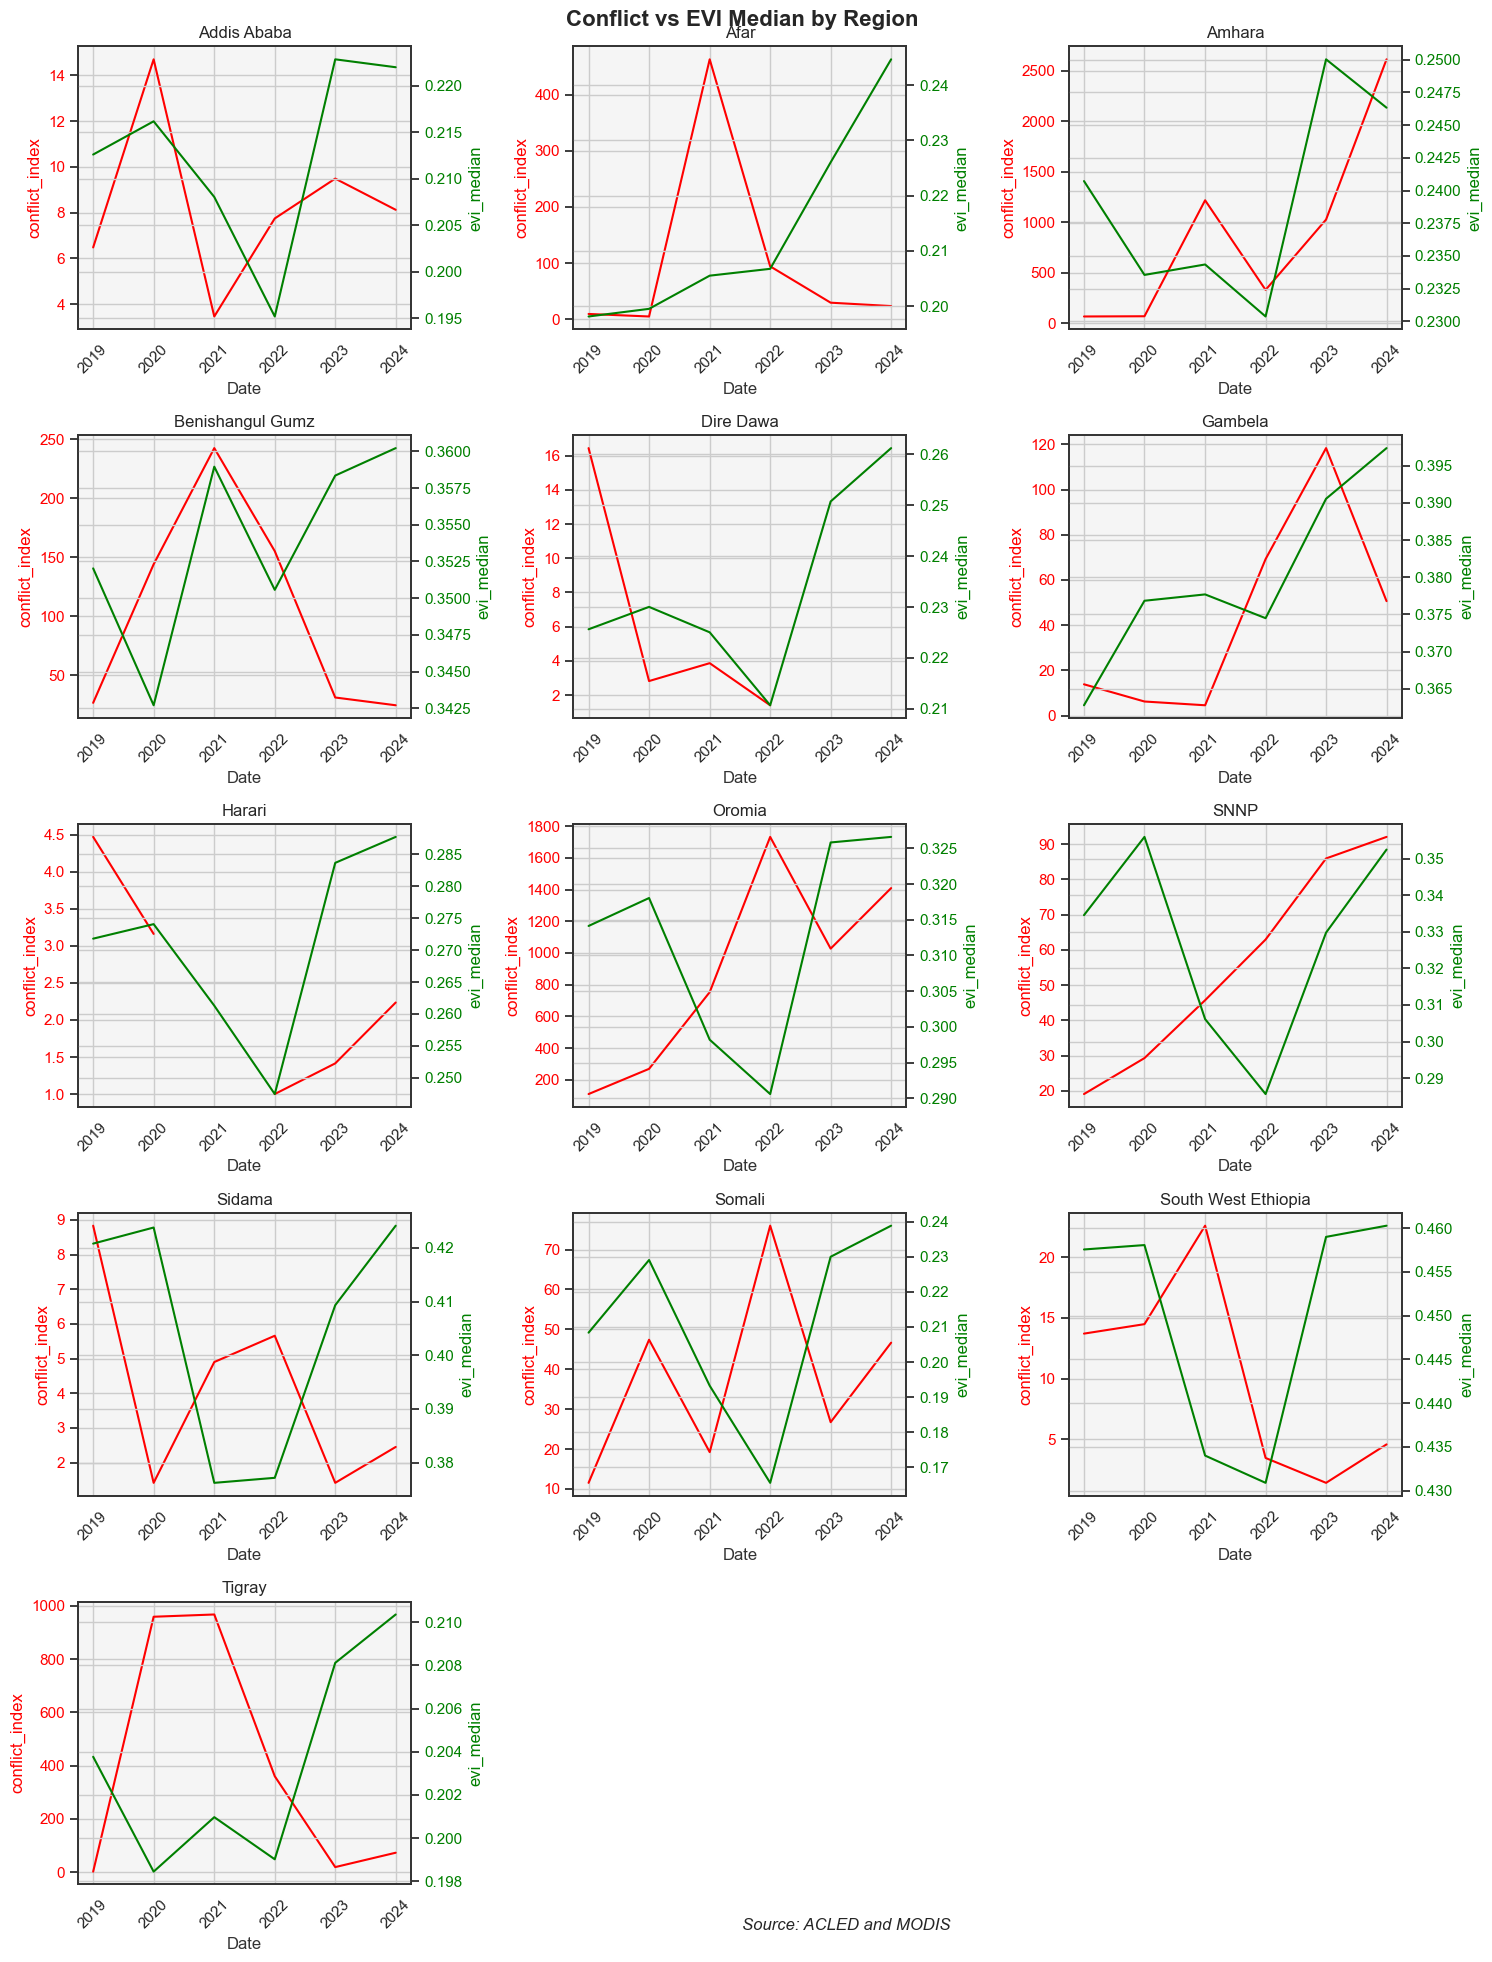

In [150]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_dual_variables(df, var1, var2, group_col='ADM1_EN', date_col='date', 
                      title='Dual Variable Analysis', subtitle='', 
                      var1_color='red', var2_color='green', cols=3):
   """
   Plot two variables over time for each group with dual y-axes
   
   Parameters:
   df: DataFrame with the data
   var1, var2: column names to plot
   group_col: column to group by (default: 'ADM1_EN')
   date_col: date column for x-axis
   title: main title
   subtitle: subtitle text
   var1_color, var2_color: colors for the lines
   cols: number of columns in subplot grid
   """
   
   groups = df[group_col].unique()
   n_groups = len(groups)
   
   rows = (n_groups + cols - 1) // cols
   fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
   axes = axes.flatten() if n_groups > 1 else [axes]
   
   # Main title and subtitle
   fig.suptitle(title, fontsize=16, fontweight='bold')
   if subtitle:
       fig.text(0.5, 0.02, subtitle, ha='left', fontsize=12, style='italic')
   
   for i, group in enumerate(groups):
       group_data = df[df[group_col] == group].sort_values(date_col)
       
       ax = axes[i]
       ax2 = ax.twinx()
       
       # Plot variables
       ax.plot(group_data[date_col], group_data[var1], color=var1_color, label=var1)
       ax.set_ylabel(var1, color=var1_color)
       ax.tick_params(axis='y', labelcolor=var1_color)
       
       ax2.plot(group_data[date_col], group_data[var2], color=var2_color, label=var2)
       ax2.set_ylabel(var2, color=var2_color)
       ax2.tick_params(axis='y', labelcolor=var2_color)
       
       ax.set_title(group)
       ax.set_xlabel('Date')
       ax.tick_params(axis='x', rotation=45)
   
   # Hide empty subplots
   for i in range(n_groups, len(axes)):
       axes[i].set_visible(False)
   
   plt.tight_layout()
   plt.show()

plot_dual_variables(merged_adm1_annual, 'conflict_index', 'evi_median', 
                   title='Conflict vs EVI Median by Region', 
                   subtitle='Source: ACLED and MODIS')

In [151]:
airpollution_adm2_annual = airpollution_adm2.groupby(['ADM2_EN','ADM1_EN', pd.Grouper(key='date', freq='YS')])['NO2'].mean().reset_index()
conflict_adm2_annual = get_conflict_index(conflict_adm2_annual)
evi_adm2_annual.rename(columns={'admin_area': 'ADM2_EN'}, inplace=True)
evi_adm2_annual['date'] = pd.to_datetime(evi_adm2_annual['date'])
evi_adm2_annual.rename(columns={'mean': 'evi_median'}, inplace=True)
merged_adm2_annual = pd.merge(airpollution_adm2_annual, conflict_adm2_annual, on=['date', 'ADM1_EN', 'ADM2_EN'], how='left')
merged_adm2_annual = pd.merge(merged_adm2_annual, evi_adm2_annual, on=['date', 'ADM2_EN'], how='left')

### Conflict and EVI in Zones

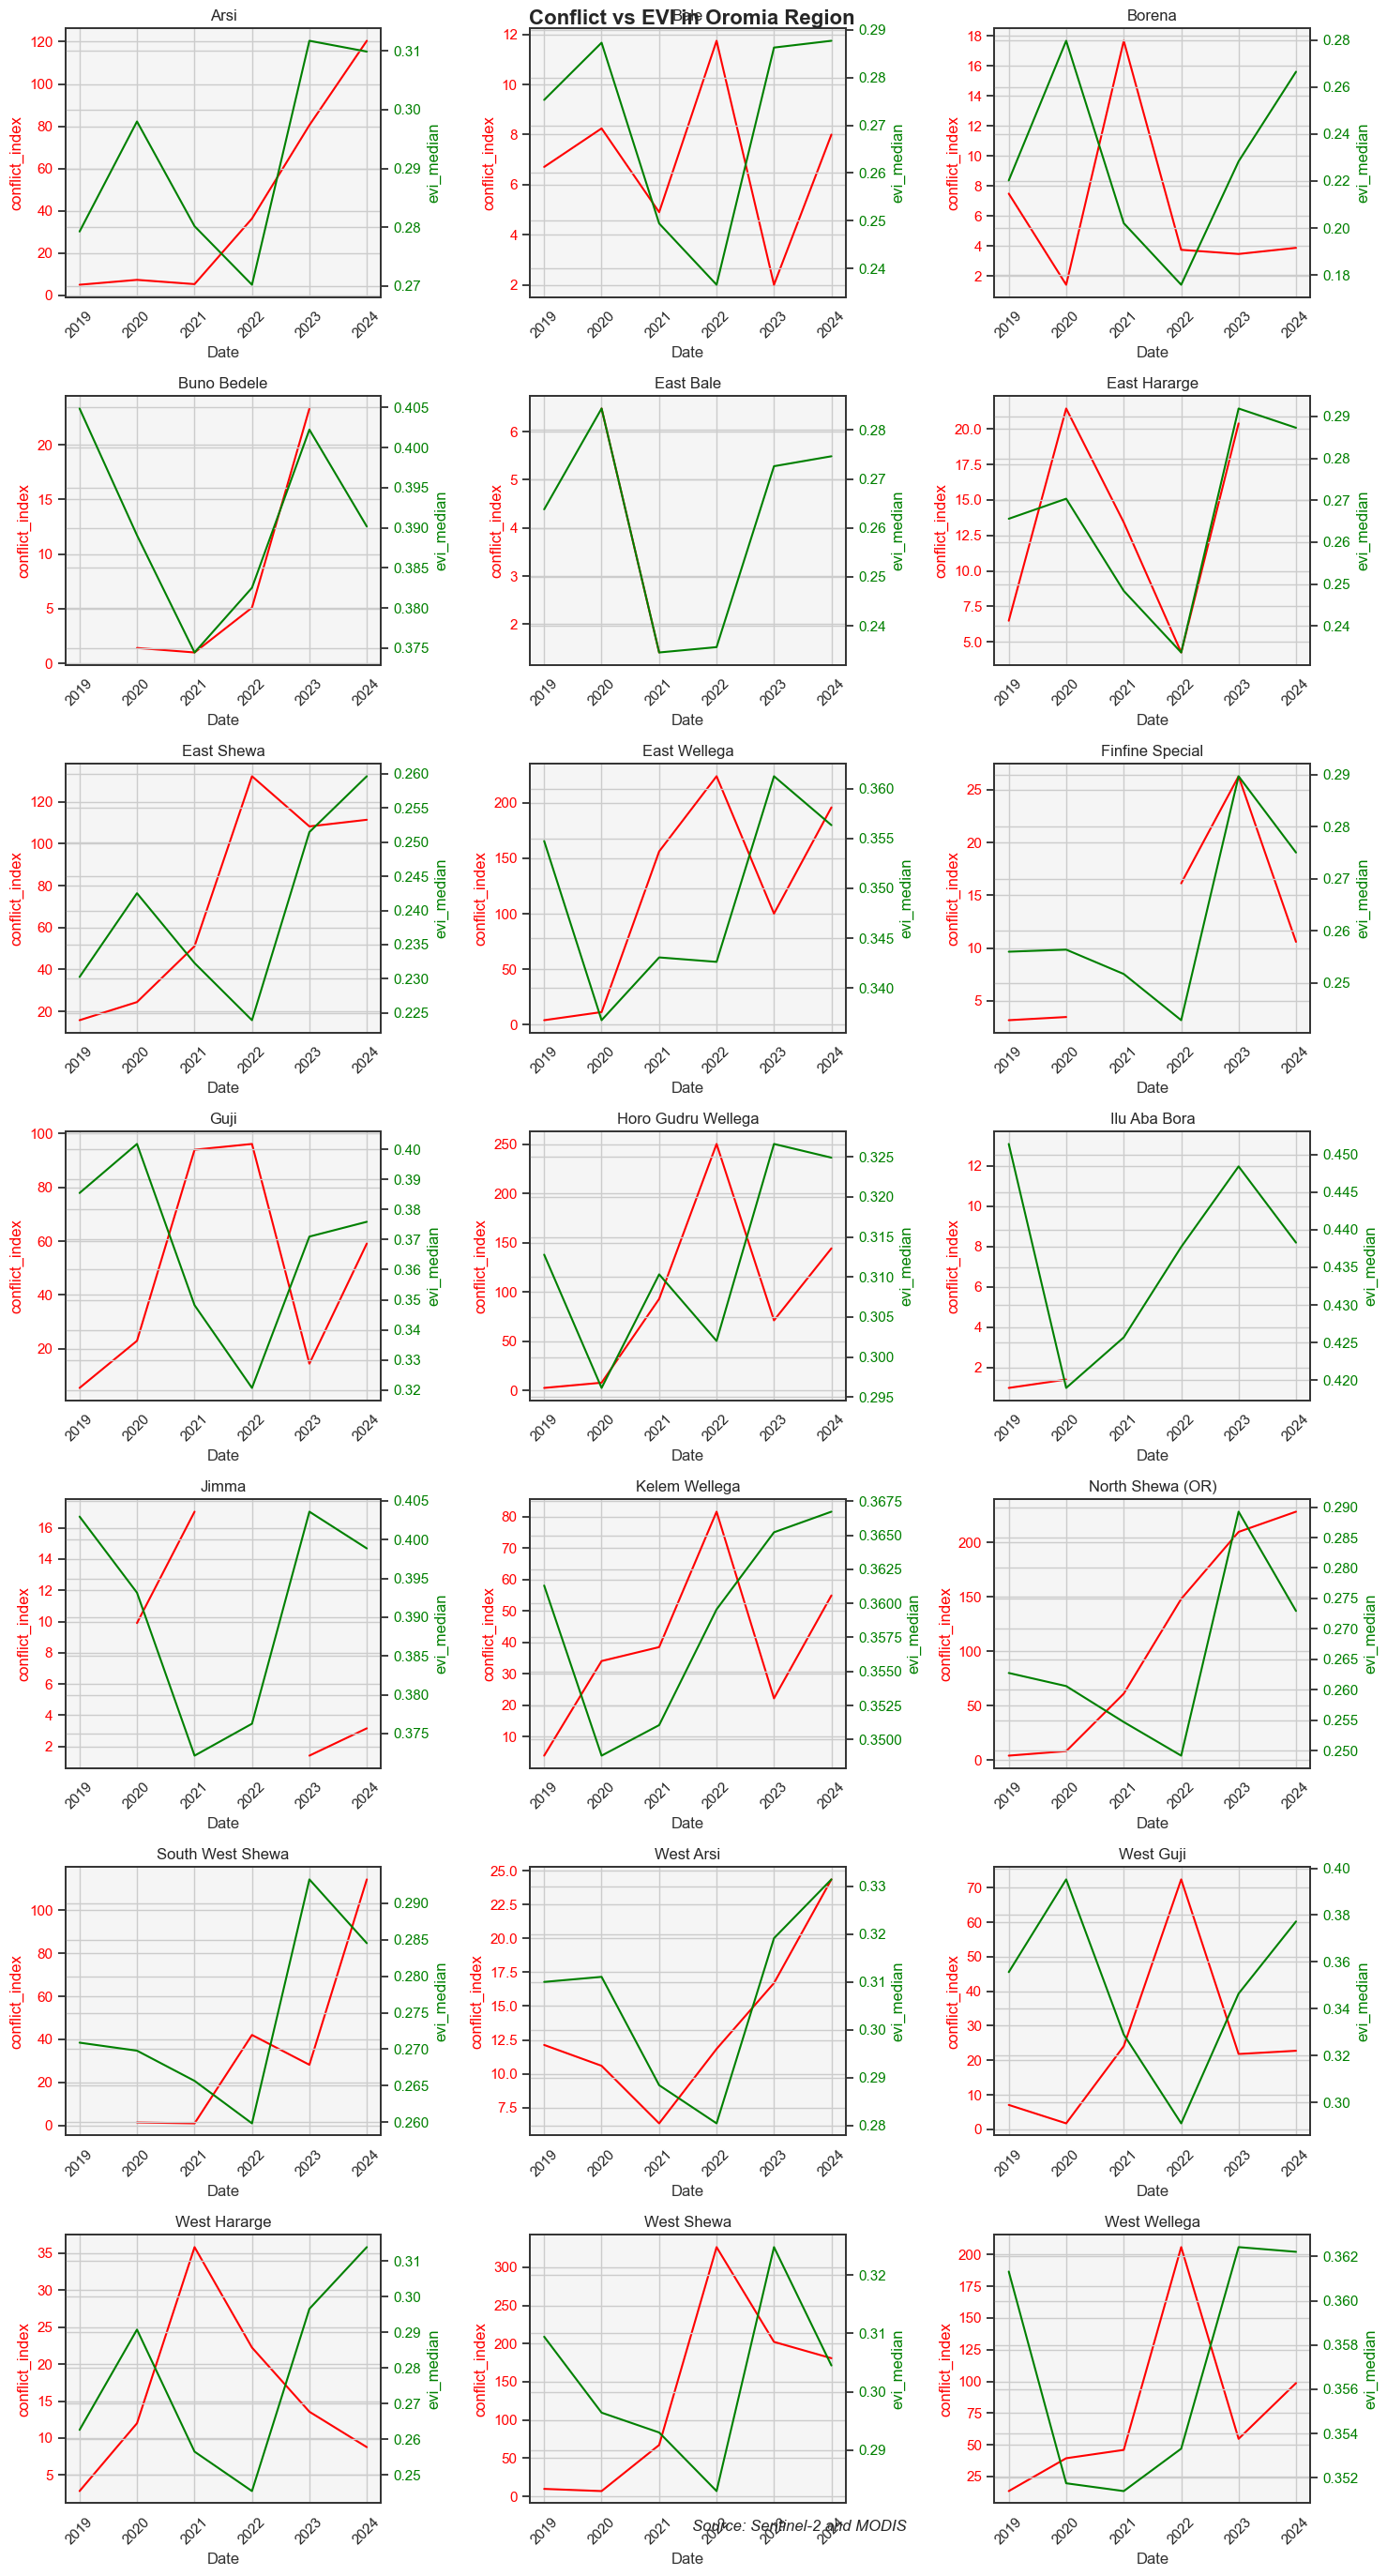

In [184]:
df = merged_adm2_annual[merged_adm2_annual['ADM1_EN'] == 'Oromia']
plot_dual_variables(df, 'conflict_index', 'evi_median', 
                   title='Conflict vs EVI in Oromia Region', 
                   subtitle='Source: Sentinel-2 and MODIS', group_col='ADM2_EN')

In [185]:
conflict_adm2_events = acled_conflict_analysis.processing.get_acled_by_admin(eth_adm2, conflict, ['ADM1_EN', 'ADM2_EN', 'event_type'], freq='YS')
df = conflict_adm2_events[(conflict_adm2_events['ADM1_EN'] == 'Oromia')&(conflict_adm2_events['event_date']=='2024-01-01')].groupby(['ADM1_EN','ADM2_EN', 'event_type', 'event_date']).sum().reset_index()
df = get_conflict_index(df)
df = df.pivot(index=['ADM1_EN', 'ADM2_EN', 'event_date'], columns='event_type', values='conflict_index').reset_index()
df.drop(columns=[ 'event_date', 'ADM1_EN', 'Riots'], inplace=True)
df.set_index(['ADM2_EN'], inplace=True)
#sns.heatmap(df, annot=True, fmt='.2f', cmap='coolwarm', linewidths=.5, cbar_kws={"shrink": .8})

**Do the type of conflict events in the region explain the changes in EVI?**

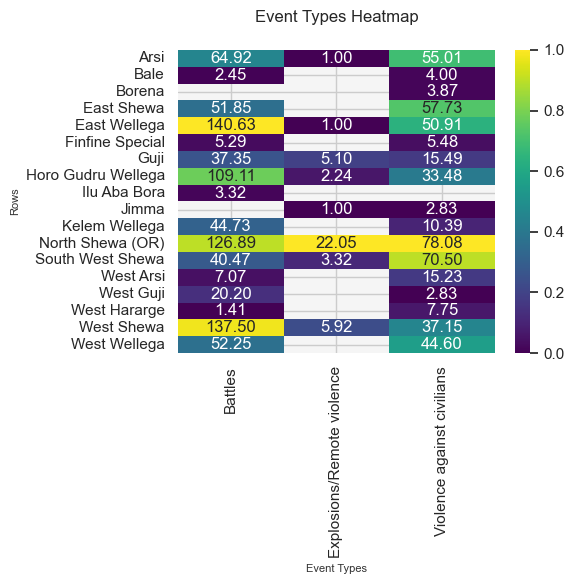

In [188]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select the event type columns
event_columns = ['Battles', 'Explosions/Remote violence', 
                 'Violence against civilians']

# Use the dataframe as is, just select the numeric columns
df_heatmap = df[event_columns]

# Normalize each column separately (0-1 scale per column)
df_normalized = df_heatmap.apply(lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else 0)

# Create the heatmap with per-column normalization
plt.figure(figsize=(6, 6))
sns.heatmap(df_normalized, 
            annot=df_heatmap,  # Show original values as annotations
            cmap='viridis',  # Color scheme
            fmt='0.2f',  # Integer format for annotations
            )

plt.title('Event Types Heatmap', fontsize=12, pad=20)
plt.xlabel('Event Types', fontsize=8)
plt.ylabel('Rows', fontsize=8)
plt.tight_layout()
plt.show()

### Conflict and EVI in Amhara

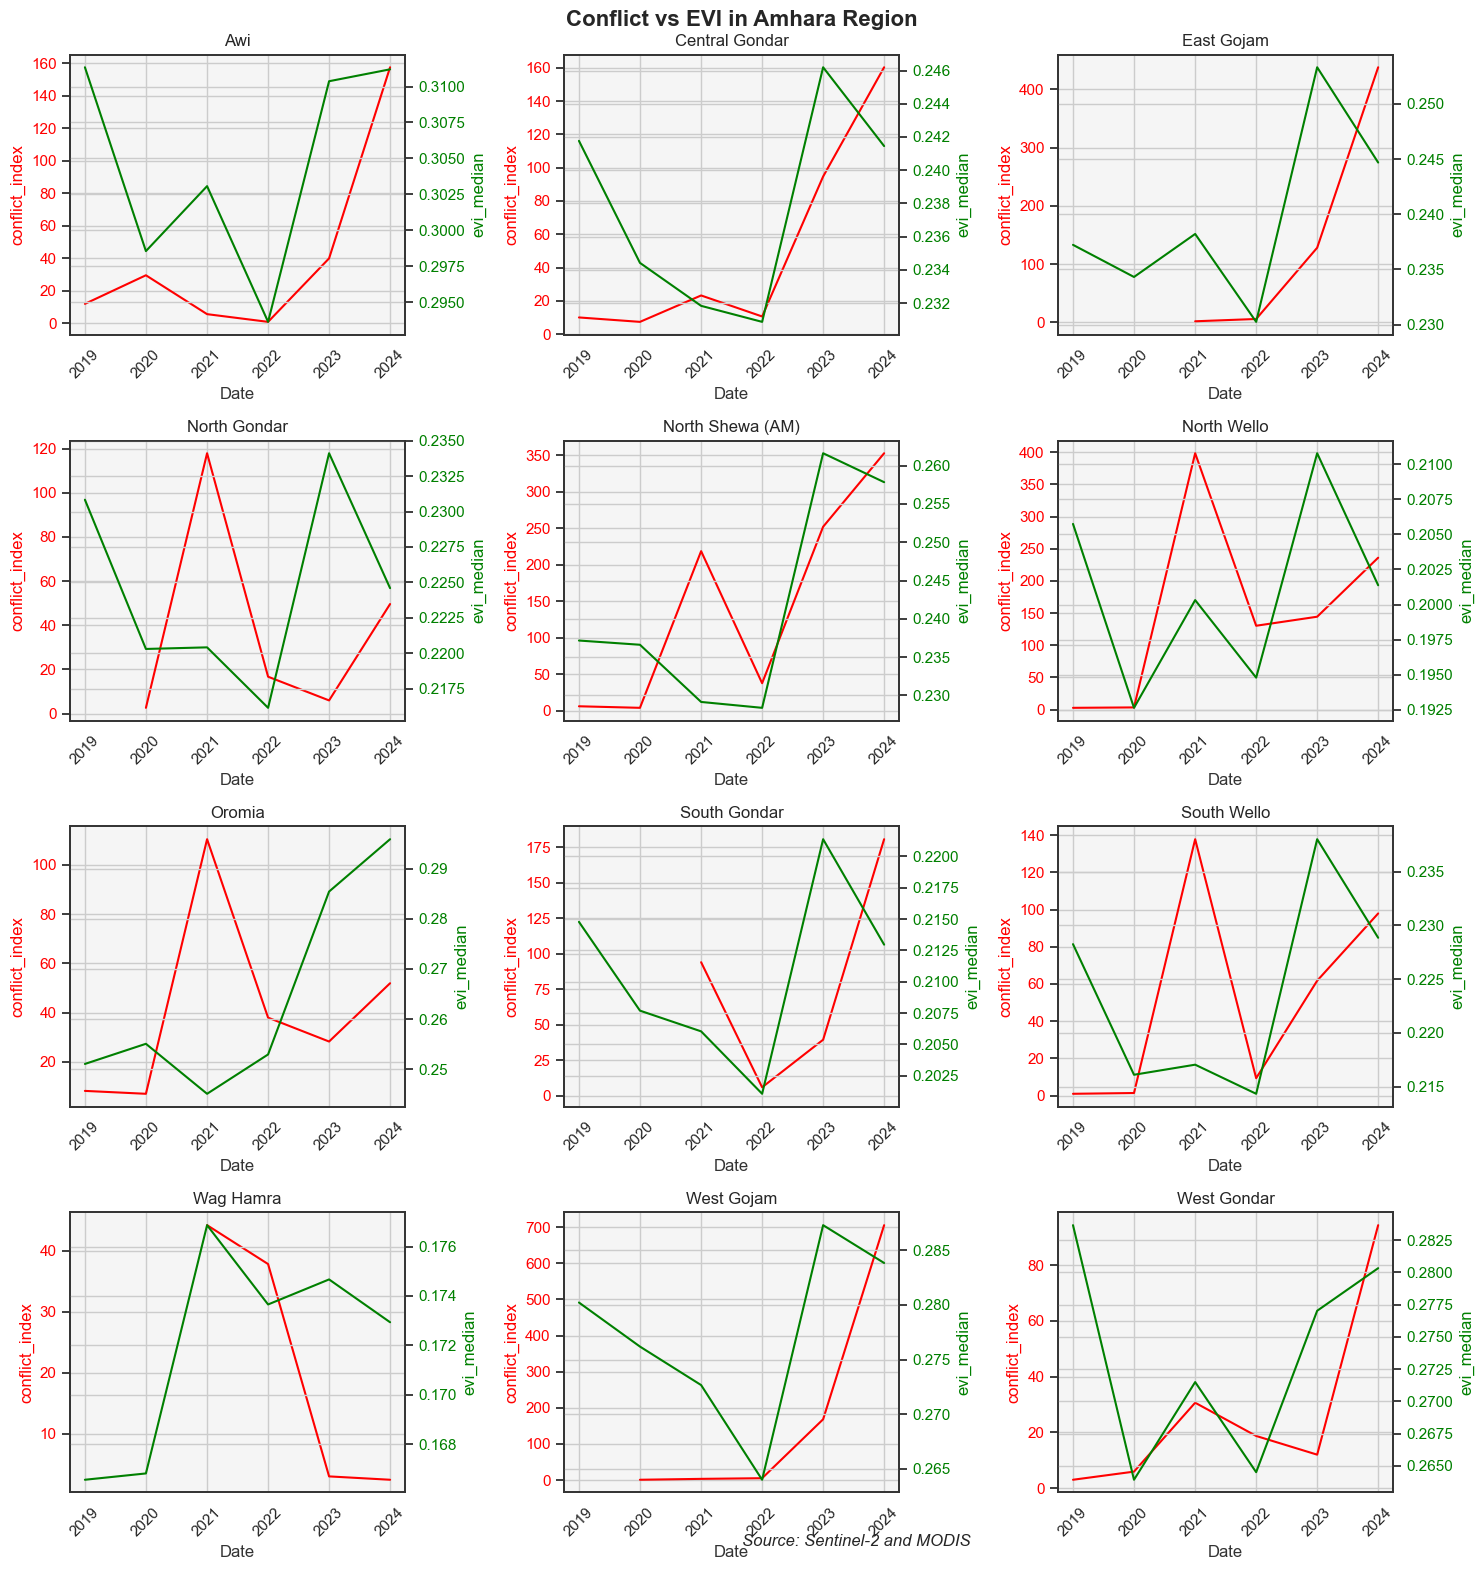

In [152]:
df = merged_adm2_annual[merged_adm2_annual['ADM1_EN'] == 'Amhara']
plot_dual_variables(df, 'conflict_index', 'evi_median', 
                   title='Conflict vs EVI in Amhara Region', 
                   subtitle='Source: Sentinel-2 and MODIS', group_col='ADM2_EN')

**Oromia, Awi and West Gondar did not see a reduction in EVI. Could it be because of a different type of conflict in that region?**

In [168]:
conflict_adm2_events = acled_conflict_analysis.processing.get_acled_by_admin(eth_adm2, conflict, ['ADM1_EN', 'ADM2_EN', 'event_type'], freq='YS')
df = conflict_adm2_events[(conflict_adm2_events['ADM1_EN'] == 'Amhara')&(conflict_adm2_events['event_date']=='2024-01-01')].groupby(['ADM1_EN','ADM2_EN', 'event_type', 'event_date']).sum().reset_index()
df = get_conflict_index(df)
df = df.pivot(index=['ADM1_EN', 'ADM2_EN', 'event_date'], columns='event_type', values='conflict_index').reset_index()
df.drop(columns=[ 'event_date', 'ADM1_EN', 'Riots'], inplace=True)
df.set_index(['ADM2_EN'], inplace=True)
#sns.heatmap(df, annot=True, fmt='.2f', cmap='coolwarm', linewidths=.5, cbar_kws={"shrink": .8})

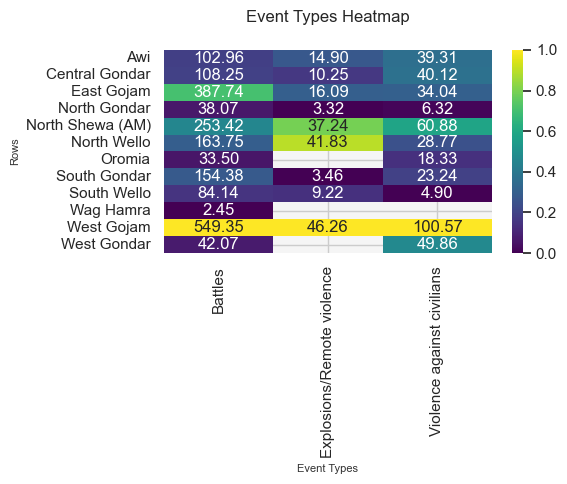

In [182]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select the event type columns
event_columns = ['Battles', 'Explosions/Remote violence', 
                 'Violence against civilians']

# Use the dataframe as is, just select the numeric columns
df_heatmap = df[event_columns]

# Normalize each column separately (0-1 scale per column)
df_normalized = df_heatmap.apply(lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else 0)

# Create the heatmap with per-column normalization
plt.figure(figsize=(6, 5))
sns.heatmap(df_normalized, 
            annot=df_heatmap,  # Show original values as annotations
            cmap='viridis',  # Color scheme
            fmt='0.2f',  # Integer format for annotations
            )

plt.title('Event Types Heatmap', fontsize=12, pad=20)
plt.xlabel('Event Types', fontsize=8)
plt.ylabel('Rows', fontsize=8)
plt.tight_layout()
plt.show()

Oromia and West Gondar had lower battle conflict intensity comparatively. However, this doesn't explain why Awi shows no reduction in EVI. 

## Annual Regional Trends between Conflict and NO2

Literature shows that conflict could reduce NO2 overall in the country although regional trends may not follow suit. 

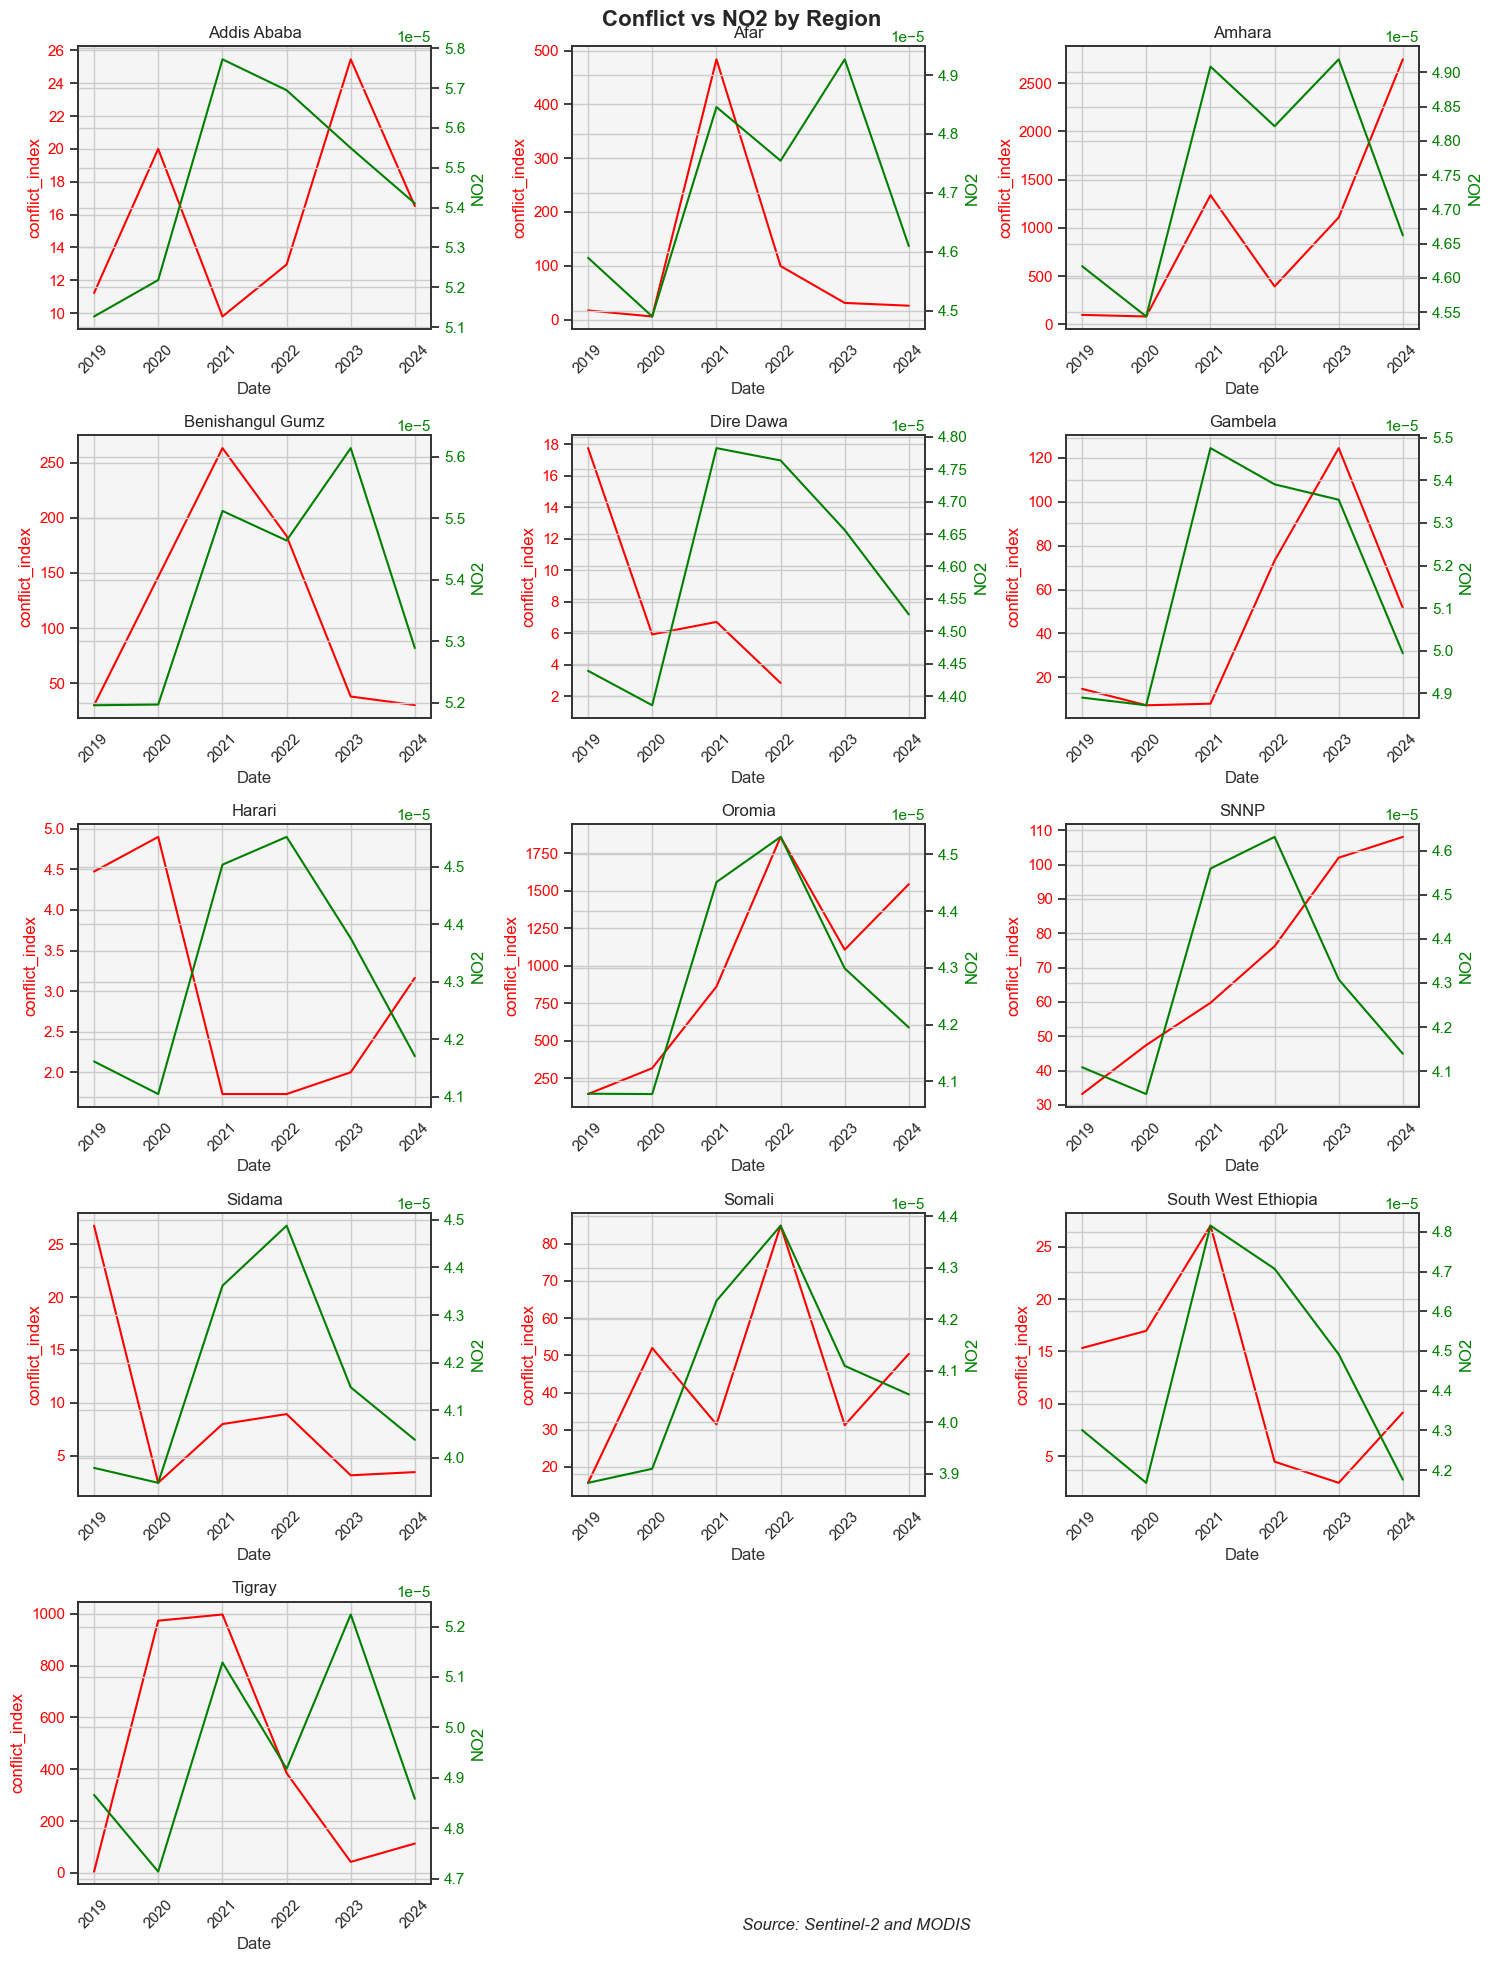

In [71]:
plot_dual_variables(merged_adm1_annual, 'conflict_index', 'NO2', 
                   title='Conflict vs NO2 by Region', 
                   subtitle='Source: Sentinel-2 and MODIS')

### Conflict vs NO2 in Amhara

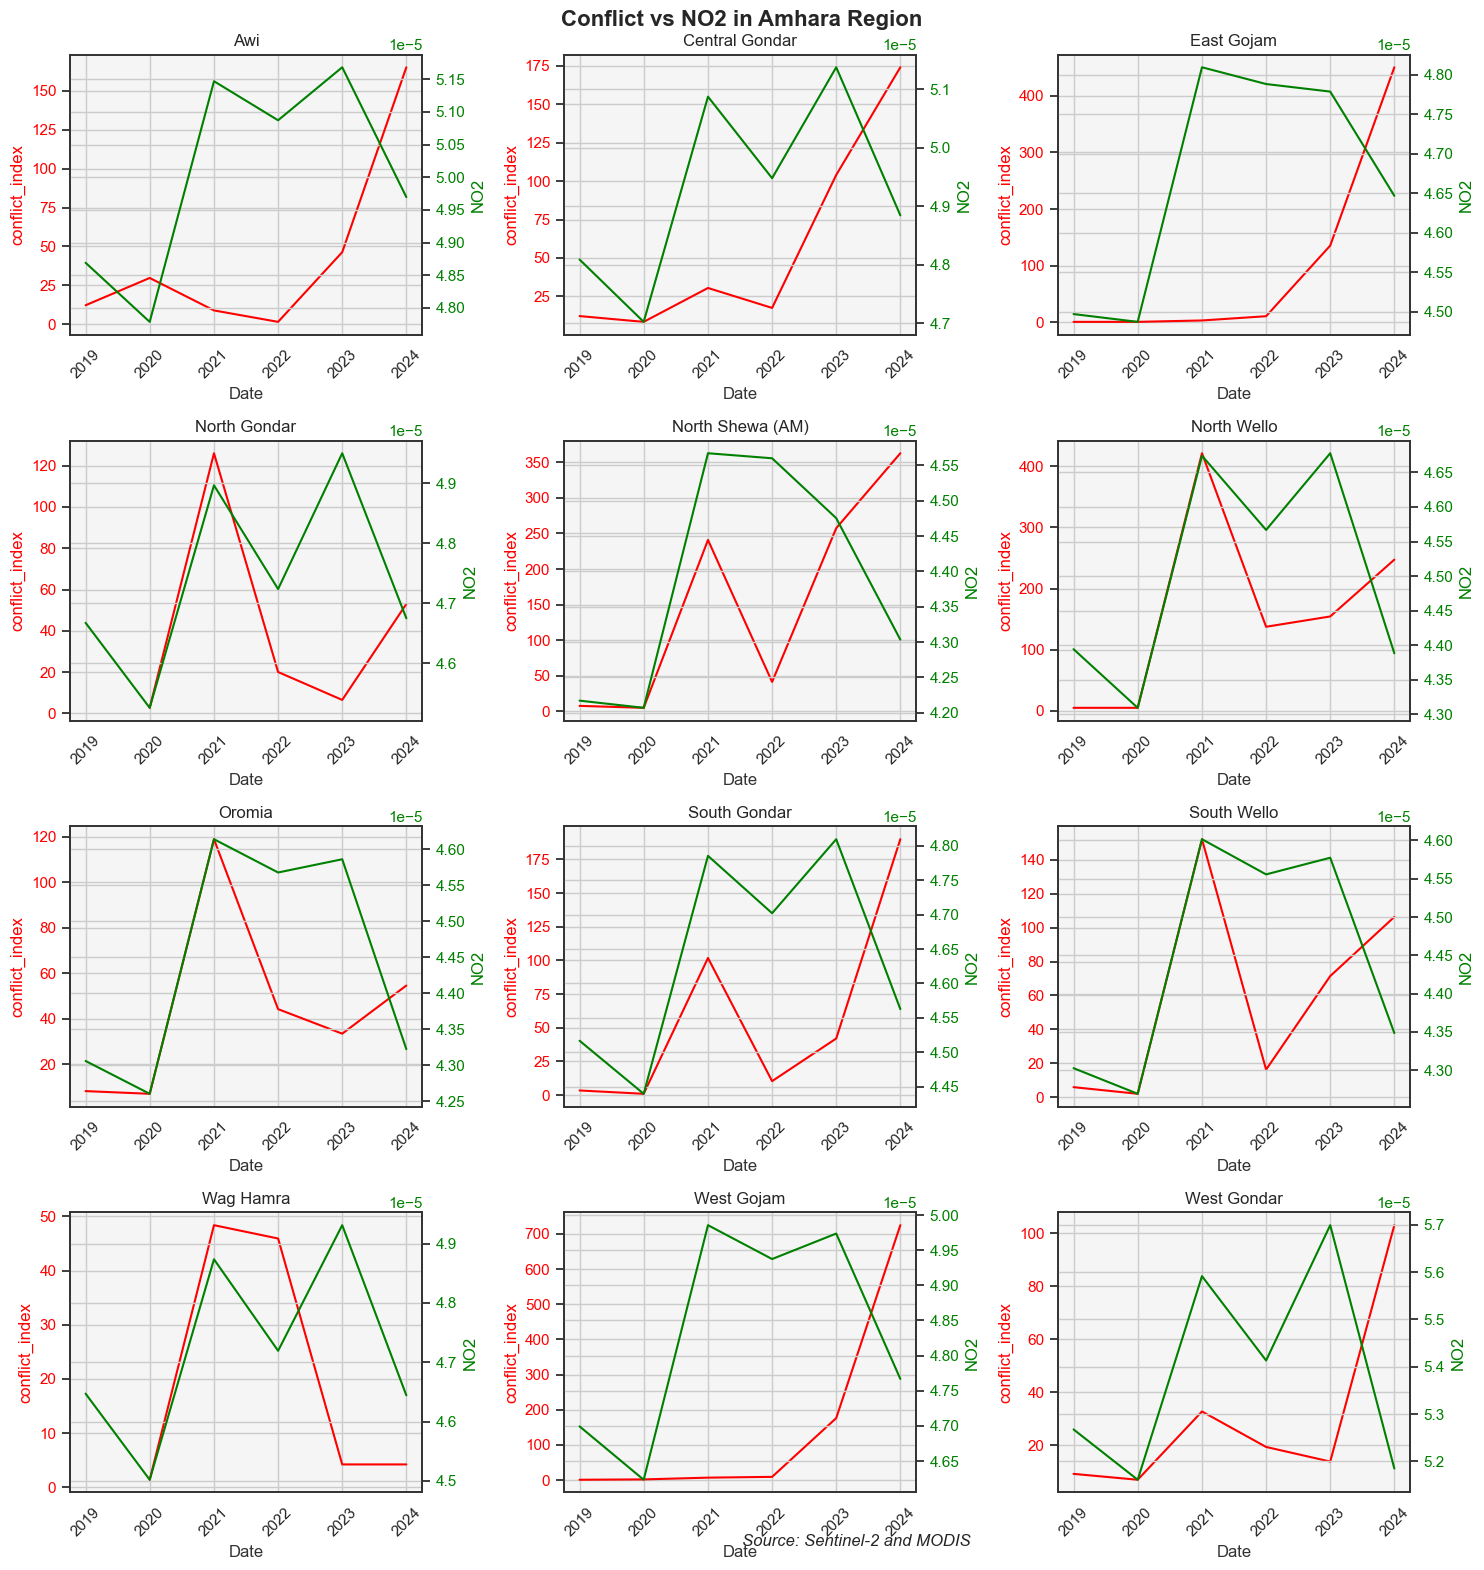

In [85]:
df = merged_adm2_annual[merged_adm2_annual['ADM1_EN'] == 'Amhara']
plot_dual_variables(df, 'conflict_index', 'NO2', 
                   title='Conflict vs NO2 in Amhara Region', 
                   subtitle='Source: Sentinel-2 and MODIS', group_col='ADM2_EN')

In [115]:
conflict_evi = pd.merge(conflict_adm2_monthly, evi_adm2_monthly, on=['date', 'ADM2_EN'], how='inner')

In [183]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Define variables
variables = ['conflict_index', 'evi_median', 'NO2', 'ntl_sum', 'GDP (current US$)']

def create_correlation_heatmaps(df, variables):
    """
    Create two heatmaps: one for correlations and one for p-values
    """
    
    # Clean data
    subset_df = df[variables].dropna()
    n_vars = len(variables)
    
    print(f"Sample size: {len(subset_df)} observations")
    
    # Calculate correlation and p-value matrices
    corr_matrix = pd.DataFrame(np.zeros((n_vars, n_vars)), 
                              index=variables, columns=variables)
    p_matrix = pd.DataFrame(np.zeros((n_vars, n_vars)), 
                           index=variables, columns=variables)
    
    for i, var1 in enumerate(variables):
        for j, var2 in enumerate(variables):
            if i == j:
                corr_matrix.iloc[i, j] = 1.0
                p_matrix.iloc[i, j] = 0.0
            else:
                corr, p_val = pearsonr(subset_df[var1], subset_df[var2])
                corr_matrix.iloc[i, j] = corr
                p_matrix.iloc[i, j] = p_val
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Heatmap 1: Correlation Matrix
    sns.heatmap(corr_matrix, 
                annot=True, 
                cmap='RdBu_r', 
                center=0, 
                square=True, 
                fmt='.3f', 
                cbar_kws={"shrink": .8},
                ax=ax1,
                vmin=-1, 
                vmax=1)
    ax1.set_title('Correlation Matrix\n(Pearson Correlation Coefficients)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('')
    ax1.set_ylabel('')
    
    # Heatmap 2: P-Value Matrix
    sns.heatmap(p_matrix, 
                annot=True, 
                cmap='viridis_r', 
                square=True, 
                fmt='.4f', 
                cbar_kws={"shrink": .8, "label": "P-Value"},
                ax=ax2,
                vmin=0,
                vmax=1)
    ax2.set_title('P-Value Matrix\n(Statistical Significance)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('')
    ax2.set_ylabel('')
    
    # Add significance indicators to p-value heatmap
    for i in range(len(variables)):
        for j in range(len(variables)):
            p_val = p_matrix.iloc[i, j]
            if p_val < 0.001:
                significance = '***'
            elif p_val < 0.01:
                significance = '**'
            elif p_val < 0.05:
                significance = '*'
            else:
                significance = ''
            
            if significance and i != j:  # Don't add stars to diagonal
                ax2.text(j + 0.5, i + 0.7, significance, 
                        ha='center', va='center', color='white', fontweight='bold', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary of significant correlations
    print("\nSIGNIFICANT CORRELATIONS SUMMARY:")
    print("=" * 50)
    
    significant_pairs = []
    for i, var1 in enumerate(variables):
        for j, var2 in enumerate(variables):
            if i < j:  # Avoid duplicates
                corr_val = corr_matrix.iloc[i, j]
                p_val = p_matrix.iloc[i, j]
                
                if p_val < 0.05:
                    if p_val < 0.001:
                        sig_level = "***"
                    elif p_val < 0.01:
                        sig_level = "**"
                    else:
                        sig_level = "*"
                    
                    significant_pairs.append({
                        'Variable 1': var1,
                        'Variable 2': var2,
                        'Correlation': corr_val,
                        'P-Value': p_val,
                        'Significance': sig_level
                    })
    
    if significant_pairs:
        sig_df = pd.DataFrame(significant_pairs)
        sig_df = sig_df.sort_values('P-Value')
        
        print("Significant correlations (p < 0.05):")
        for _, row in sig_df.iterrows():
            print(f"  {row['Variable 1']} ↔ {row['Variable 2']}: r = {row['Correlation']:.3f}, p = {row['P-Value']:.4f} {row['Significance']}")
    else:
        print("No significant correlations found at p < 0.05 level")
    
    # Key findings for conflict_index vs evi_median
    conflict_evi_corr = corr_matrix.loc['conflict_index', 'evi_median']
    conflict_evi_p = p_matrix.loc['conflict_index', 'evi_median']
    
    print(f"\nKEY FINDING - CONFLICT vs EVI:")
    print("=" * 50)
    print(f"Correlation: {conflict_evi_corr:.4f}")
    print(f"P-value: {conflict_evi_p:.6f}")
    
    if conflict_evi_corr < 0:
        direction = "NEGATIVE - Higher conflict associated with lower EVI (supports hypothesis)"
    elif conflict_evi_corr > 0:
        direction = "POSITIVE - Higher conflict associated with higher EVI (contradicts hypothesis)"
    else:
        direction = "ZERO - No linear relationship"
    
    if conflict_evi_p < 0.05:
        significance = "STATISTICALLY SIGNIFICANT"
    else:
        significance = "NOT STATISTICALLY SIGNIFICANT"
    
    print(f"Direction: {direction}")
    print(f"Significance: {significance}")
    
    return corr_matrix, p_matrix

